<a href="https://colab.research.google.com/github/JMMV314/ANE2_procesamiento/blob/main/V01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import time
from contextlib import contextmanager

warnings.filterwarnings("ignore")

try:
    from google.colab import files
except:
    files = None

@contextmanager
def _timer(label, timers_dict):
    start = time.perf_counter()
    yield
    elapsed = time.perf_counter() - start
    timers_dict[label] = elapsed
    print(f"   {label}: {elapsed:.4f} s")

class DigitalSignalProcessing:
    def __init__(self, file_path=None, f_start=None, f_stop=None, gain_dBi=0, bins=128, delta_dB=0.5):
        """
        DSP pipeline with per-step timing
        """
        self.file_path = file_path
        self.f_start = f_start
        self.f_stop = f_stop
        self.gain_dBi = gain_dBi
        self.bins = bins
        self.delta_dB = delta_dB
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.peaks_df = None
        self.timers = {}  # Store timing for each step

        print(f"\n{'='*60}")
        print(f"  STARTING DSP PIPELINE")
        print(f"{'='*60}\n")

        # --- Upload if no file ---
        if self.file_path is None and files is not None:
            with _timer("Upload CSV", self.timers):
                print("No file path — uploading...")
                uploaded = files.upload()
                self.file_path = list(uploaded.keys())[0]
                print(f"Uploaded: {self.file_path}")

        if self.file_path is None:
            raise ValueError("No file provided.")

        self.file_path = Path(self.file_path)

        # Pipeline with timing
        with _timer("Load CSV", self.timers):
            self._load_csv()

        with _timer("Convert to dBm/Hz", self.timers):
            self._convert_to_dBm_per_Hz()

        if self.f_start is not None and self.f_stop is not None:
            with _timer("Apply Gain Correction", self.timers):
                self._apply_gain_correction()

            with _timer("Estimate Noise Floor", self.timers):
                self._estimate_noise_floor()

            with _timer("Detect Peaks & BW", self.timers):
                self._detect_peaks_threshold()

            print(f"\nProcessing completed.")
            print(f"Noise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz\n")

            # Auto plots with timing
            with _timer("Plot: Original vs Corrected", self.timers):
                self.plot_comparison("Original vs Gain-Corrected PSD")

            with _timer("Plot: PSD + Noise Floor", self.timers):
                self.plot_with_noise("Gain-Corrected PSD with Noise Floor")

            with _timer("Plot: Detected Peaks", self.timers):
                self.plot_detected_peaks("Detected Peaks (-3 dB BW)")

        else:
            print("No frequency range → skipping analysis.")

        # Final timing summary
        self._print_timing_summary()

    # ---------------------------------------------------------------
    # 1) Load CSV
    # ---------------------------------------------------------------
    def _load_csv(self):
        self.df = pd.read_csv(self.file_path)
        required = ['Frecuencia (Hz)', 'PSD']
        if not all(col in self.df.columns for col in required):
            raise ValueError(f"CSV must contain: {required}")
        self.df = self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'})
        self.df = self.df.dropna().drop_duplicates(subset=['freq_Hz'])
        self.df = self.df.sort_values(by='freq_Hz').reset_index(drop=True)
        print(f"   Loaded {len(self.df):,} samples | "
              f"{self.df['freq_Hz'].min()/1e6:.3f} – {self.df['freq_Hz'].max()/1e6:.3f} MHz")

    # ---------------------------------------------------------------
    # 2) Convert PSD to dBm/Hz
    # ---------------------------------------------------------------
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz'].copy()
        if psd.mean() < 0:
            print("   Detected dB-scaled PSD → converting to linear")
            psd_linear = 10 ** (psd / 10.0)
        else:
            psd_linear = psd
        psd_WHz = np.maximum(psd_linear / 50.0, 1e-18)
        self.df['psd_dBmHz'] = 10 * np.log10(psd_WHz) + 30

    # ---------------------------------------------------------------
    # 3) Apply gain correction
    # ---------------------------------------------------------------
    def _apply_gain_correction(self):
        self.df['psd_corr_dBmHz'] = self.df['psd_dBmHz'].copy()
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        self.df.loc[mask, 'psd_corr_dBmHz'] -= self.gain_dBi
        print(f"   Applied {self.gain_dBi:+.1f} dBi in "
              f"[{self.f_start/1e6:.2f}, {self.f_stop/1e6:.2f}] MHz")

    # ---------------------------------------------------------------
    # 4) Estimate noise floor
    # ---------------------------------------------------------------
    def _estimate_noise_floor(self, max_iter=5, clip_pct=75, window_dB=6.0):
        x = self.df['psd_corr_dBmHz'].to_numpy()
        for i in range(max_iter):
            clip_val = np.percentile(x, clip_pct)
            x_clip = x[x <= clip_val]
            if len(x_clip) < 10:
                break
            counts, edges = np.histogram(x_clip, bins=self.bins)
            mode_idx = np.argmax(counts)
            mode_center = (edges[mode_idx] + edges[mode_idx + 1]) / 2
            mask = (x_clip >= mode_center - window_dB/2) & (x_clip <= mode_center + window_dB/2)
            if mask.sum() < 10:
                break
            x = x_clip[mask]
        self.noise_floor_dBmHz_ = float(np.mean(x))

    # ---------------------------------------------------------------
    # 5) Detect peaks + -3 dB BW
    # ---------------------------------------------------------------
    def _detect_peaks_threshold(self):
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Run _estimate_noise_floor() first.")
        y = self.df['psd_corr_dBmHz'].to_numpy()
        f = self.df['freq_Hz'].to_numpy()
        threshold = self.noise_floor_dBmHz_ + self.delta_dB

        peaks = []
        in_peak = False
        start_idx = None

        for i in range(len(y)):
            if not in_peak and y[i] > threshold:
                in_peak = True
                start_idx = i
            elif in_peak and y[i] <= threshold:
                self._process_peak(f, y, start_idx, i, threshold, peaks)
                in_peak = False

        if in_peak:
            self._process_peak(f, y, start_idx, len(y), threshold, peaks)

        if not peaks:
            print(f"   No peaks above {threshold:.2f} dBm/Hz")
            self.peaks_df = pd.DataFrame()
            return

        self.peaks_df = pd.DataFrame(peaks,
            columns=['f_center_Hz', 'amplitude_dBmHz', 'bandwidth_Hz'])
        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz'] / 1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz'] / 1e3

        print(f"   Detected {len(self.peaks_df)} peaks")

    def _process_peak(self, f, y, start, end, threshold, peaks):
        segment = y[start:end]
        seg_f = f[start:end]
        idx_max_rel = np.argmax(segment)
        idx_max = start + idx_max_rel
        f0 = seg_f[idx_max_rel]
        a0 = segment[idx_max_rel]
        bw = self._estimate_3dB_bandwidth(f, y, idx_max, a0)
        if bw > 0:
            peaks.append((f0, a0, bw))

    def _estimate_3dB_bandwidth(self, freqs, psd, peak_idx, peak_val):
        half = peak_val - 3.0
        i = peak_idx
        while i > 0 and psd[i] >= half:
            i -= 1
        f_low = freqs[max(0, i)]
        if i < peak_idx and i > 0:
            f_low = np.interp(half, [psd[i], psd[i+1]], [freqs[i], freqs[i+1]])

        i = peak_idx
        while i < len(psd)-1 and psd[i] >= half:
            i += 1
        f_high = freqs[min(len(psd)-1, i)]
        if i > peak_idx and i < len(psd):
            f_high = np.interp(half, [psd[i-1], psd[i]], [freqs[i-1], freqs[i]])

        return max(f_high - f_low, 0)

    # ---------------------------------------------------------------
    # Plotting
    # ---------------------------------------------------------------
    def _format_freq_axis(self, ax):
        def fmt(x, pos):
            if x >= 1e9: return f'{x/1e9:.2f}G'
            if x >= 1e6: return f'{x/1e6:.2f}M'
            if x >= 1e3: return f'{x/1e3:.1f}k'
            return f'{x:.0f}'
        ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt))
        ax.set_xlabel('Frequency')

    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns: return
        plt.figure(figsize=(11, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original', linewidth=1.3)
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Corrected', linestyle='--', linewidth=1.4)
        self._format_freq_axis(plt.gca())
        plt.ylabel('PSD (dBm/Hz)')
        plt.title(title or "Original vs Gain-Corrected PSD")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_with_noise(self, title=None):
        if self.noise_floor_dBmHz_ is None: return
        plt.figure(figsize=(11, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], color='steelblue', linewidth=1.4)
        plt.axhline(self.noise_floor_dBmHz_, color='red', linestyle='--',
                    label=f"Noise Floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz")
        self._format_freq_axis(plt.gca())
        plt.ylabel('PSD (dBm/Hz)')
        plt.title(title or "PSD with Noise Floor")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df) == 0: return
        plt.figure(figsize=(11, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='PSD', linewidth=1.2)
        plt.scatter(self.peaks_df['f_center_Hz'], self.peaks_df['amplitude_dBmHz'],
                    color='orange', zorder=5, label='Peaks')
        threshold = self.noise_floor_dBmHz_ + self.delta_dB
        plt.axhline(threshold, color='green', linestyle='--', alpha=0.7,
                    label=f'Threshold: {threshold:.2f} dBm/Hz')
        for _, r in self.peaks_df.iterrows():
            f0, bw = r['f_center_Hz'], r['bandwidth_Hz']/2
            # plt.axvspan(f0-bw, f0+bw, color='orange', alpha=0.15)
        self._format_freq_axis(plt.gca())
        plt.ylabel('PSD (dBm/Hz)')
        plt.title(title or "Peaks with -3 dB BW")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # Timing Summary
    # ---------------------------------------------------------------
    def _print_timing_summary(self):
        total = sum(self.timers.values())
        print(f"\n{'='*60}")
        print(f"  TIMING SUMMARY")
        print(f"{'='*60}")
        for step, t in self.timers.items():
            bar = "█" * int(50 * t / total) if total > 0 else ""
            print(f"  {step:25} {t:6.4f} s  [{bar}]")
        print(f"{'─'*60}")
        print(f"  {'TOTAL':25} {total:6.4f} s")
        print(f"{'='*60}\n")

    # ---------------------------------------------------------------
    # Utilities
    # ---------------------------------------------------------------
    def summary(self):
        print(f"\n{'='*50}")
        print(f" DSP SUMMARY")
        print(f"{'='*50}")
        print(f"File: {self.file_path.name}")
        print(f"Range: {self.df['freq_Hz'].min()/1e6:.3f} – {self.df['freq_Hz'].max()/1e6:.3f} MHz")
        print(f"Samples: {len(self.df):,}")
        if self.noise_floor_dBmHz_ is not None:
            print(f"Noise Floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz")
        print(f"Peaks: {len(self.peaks_df) if self.peaks_df is not None else 0}")
        print(f"{'='*50}\n")

    def export_peaks(self, path=None):
        if self.peaks_df is None or len(self.peaks_df) == 0:
            print("No peaks to export.")
            return
        path = path or f"peaks_{self.file_path.stem}.csv"
        self.peaks_df.to_csv(path, index=False)
        print(f"Exported peaks → {path}")


  STARTING DSP PIPELINE

   Loaded 4,096 samples | -10.000 – 9.995 MHz
   Load CSV: 0.0144 s
   Detected dB-scaled PSD → converting to linear
   Convert to dBm/Hz: 0.0023 s
   Applied +0.5 dBi in [-12.00, 10.00] MHz
   Apply Gain Correction: 0.0034 s
   Estimate Noise Floor: 0.0040 s
   Detected 55 peaks
   Detect Peaks & BW: 0.1069 s

Processing completed.
Noise floor: -66.63 dBm/Hz



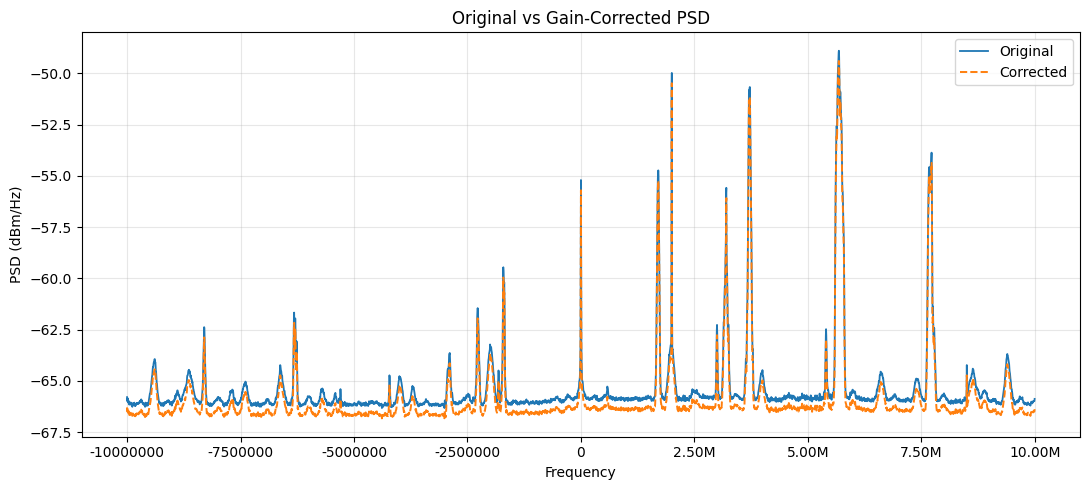

   Plot: Original vs Corrected: 0.4443 s


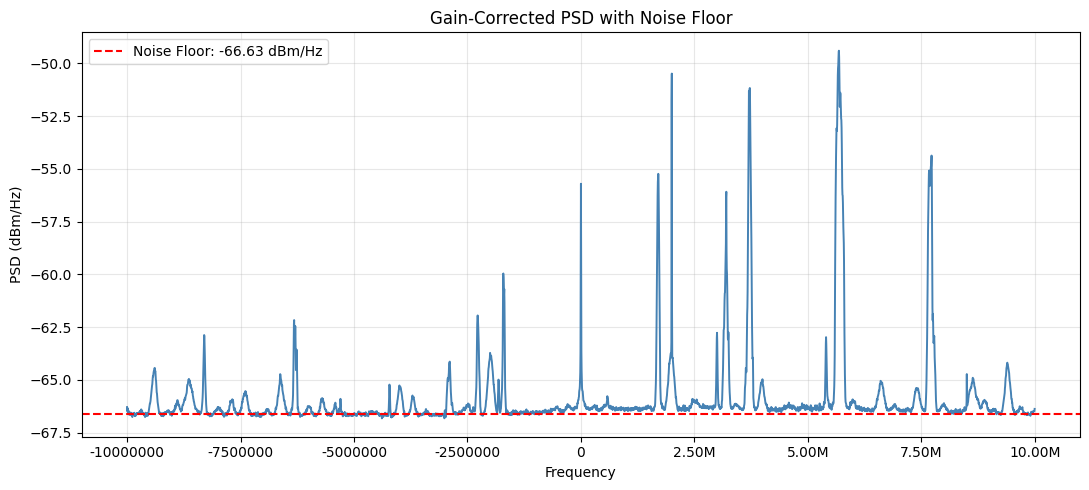

   Plot: PSD + Noise Floor: 0.2960 s


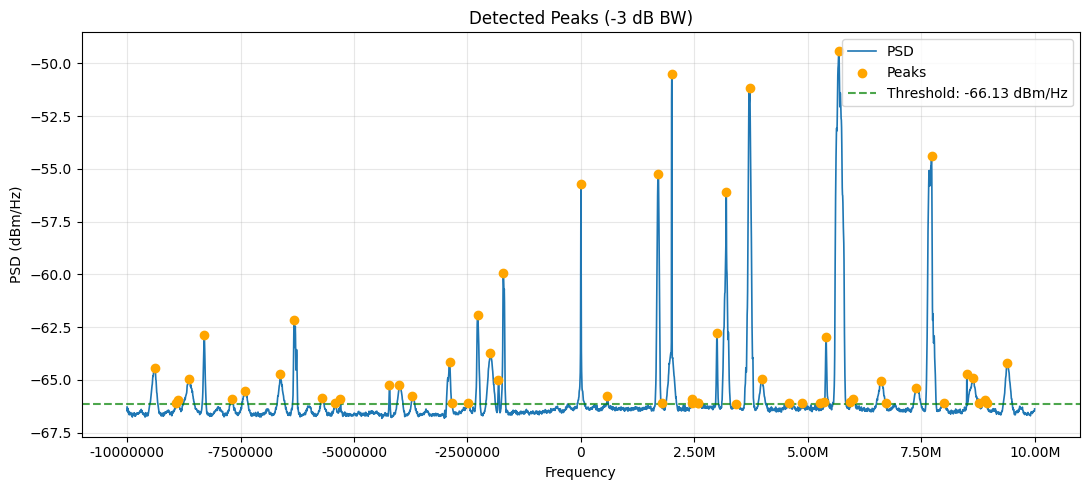

   Plot: Detected Peaks: 0.2953 s

  TIMING SUMMARY
  Load CSV                  0.0144 s  []
  Convert to dBm/Hz         0.0023 s  []
  Apply Gain Correction     0.0034 s  []
  Estimate Noise Floor      0.0040 s  []
  Detect Peaks & BW         0.1069 s  [████]
  Plot: Original vs Corrected 0.4443 s  [███████████████████]
  Plot: PSD + Noise Floor   0.2960 s  [████████████]
  Plot: Detected Peaks      0.2953 s  [████████████]
────────────────────────────────────────────────────────────
  TOTAL                     1.1667 s



In [35]:
dsp = DigitalSignalProcessing(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)